In [1]:
import pandas as pd
!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rifatalam3/gold-price-trends")

print("Path to dataset files:", path)


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]

Path to dataset files: C:\Users\Gustavo\.cache\kagglehub\datasets\rifatalam3\gold-price-trends\versions\1


In [2]:

import os

files = os.listdir(path)
print(files)

# Exemplo: carregar o primeiro arquivo CSV
df = pd.read_csv(os.path.join(path, files[0]))

print(df.head())

['finalgolddata.csv']
       Date        Open        High         Low       Close  Volume
0  30-08-00  273.899994  273.899994  273.899994  273.899994       0
1  31-08-00  274.799988  278.299988  274.799988  278.299988       0
2  01-09-00  277.000000  277.000000  277.000000  277.000000       0
3  05-09-00  275.799988  275.799988  275.799988  275.799988       2
4  06-09-00  274.200012  274.200012  274.200012  274.200012       0


In [3]:
df

,Date,Open,High,Low,Close,Volume
0,30-08-00,273.899994,273.899994,273.899994,273.899994,0
1,31-08-00,274.799988,278.299988,274.799988,278.299988,0
2,01-09-00,277.000000,277.000000,277.000000,277.000000,0
3,05-09-00,275.799988,275.799988,275.799988,275.799988,2
4,06-09-00,274.200012,274.200012,274.200012,274.200012,0
...,...,...,...,...,...,...
6394,25-02-26,5166.000000,5206.399902,5166.000000,5206.399902,1772
6395,26-02-26,5177.200195,5199.200195,5143.899902,5176.500000,1520
6396,27-02-26,5186.700195,5280.000000,5176.700195,5230.500000,354
6397,02-03-26,5346.600098,5405.000000,5266.299805,5294.399902,354


In [4]:
print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [6]:
# definir target e features 

df['Date'] = pd.to_datetime(df['Date'])
features = df[["Open", 'High', "Low", "Volume"]]
target = df[["Close"]]
x = df[["Open", 'High', "Low", "Volume"]]
y = df[["Close"]]
from sklearn import tree


C:\Users\Gustavo\AppData\Local\Temp\ipykernel_3996\1989346427.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [8]:
model = tree.DecisionTreeRegressor()
model.fit(X=x,y=y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


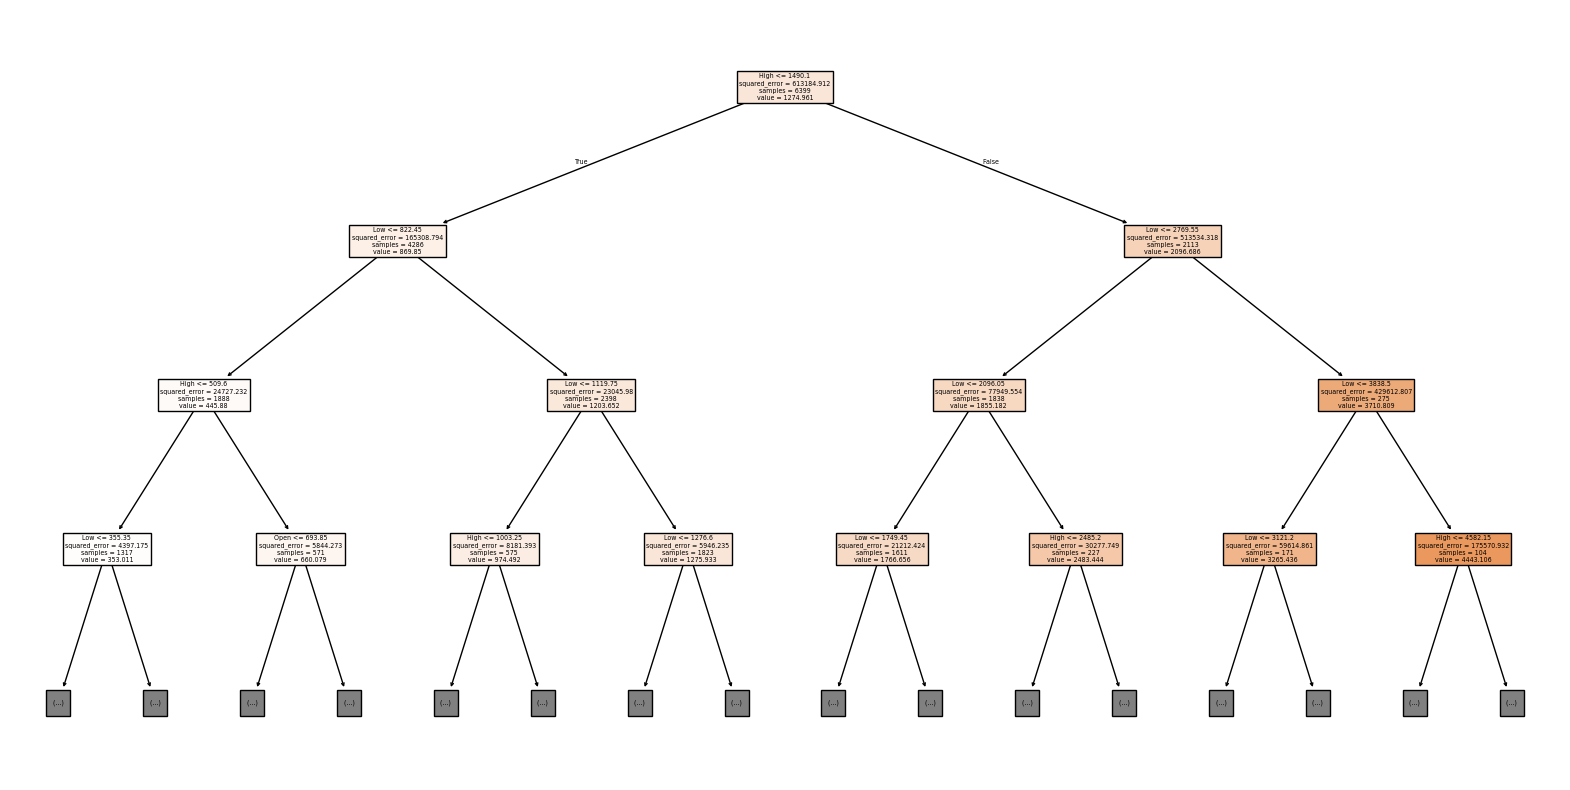

In [10]:
#Arvore de decisão

import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(20,10))
tree.plot_tree(model,
               feature_names =["Open", "High", "Low", "Volume"],filled= True, max_depth = 3)
plt.show()


In [13]:
y_predito = model.predict(x)

print(y_predito[:5])

[273.8999939 278.2999878 277.        275.7999878 274.2000122]


In [16]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y, y_predito)
print(f"Erro Médio Absoluto: {mae}")

Erro Médio Absoluto: 0.014325120018753084


In [22]:
## erro absoluto baixo indica que os dados já conhecidos ele acertou tudo

In [18]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, x_test, Y_train, y_test = train_test_split(x,y, test_size= 0.2)
model.fit(X_train, Y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [21]:
predicoes_teste = model.predict(x_test)
print(mean_absolute_error(y_test, predicoes_teste))

6.308081832421877


## tentar diminiur o erro que é 6.3 com dados novos


In [24]:
from sklearn.ensemble import RandomForestRegressor

In [27]:
rf_model = RandomForestRegressor(n_estimators=100, random_state = 42)

#treinar modelo
rf_model.fit(X_train, Y_train.values.ravel())

#fazendo as predições de teste

rf_predicoes = rf_model.predict(x_test)

In [29]:
mae_rf = mean_absolute_error(y_test, rf_predicoes)
print(f"Errro médio Absoluto(Árvore Simples): 6.30")
print(f"Errro médio Absoluto(Random Frorest): {mae_rf:.4f}")

Errro médio Absoluto(Árvore Simples): 6.30
Errro médio Absoluto(Random Frorest): 4.6856


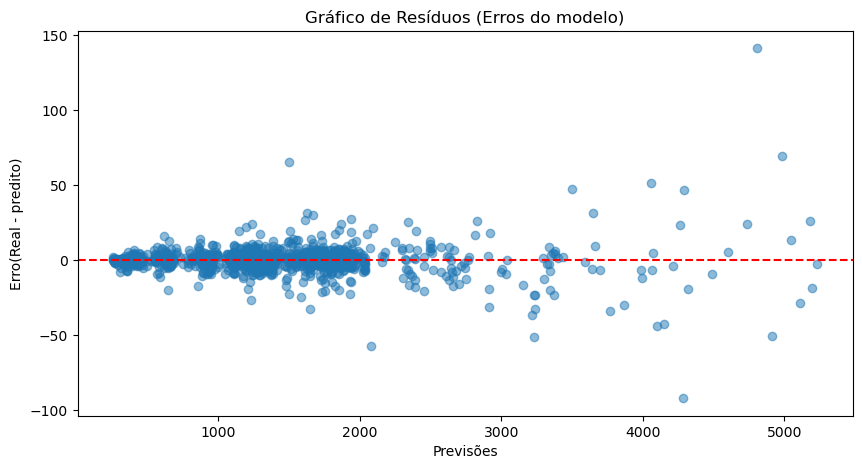

In [30]:
residuos = y_test.values.ravel() - rf_predicoes

plt.figure(figsize=(10, 5))
plt.scatter(rf_predicoes, residuos, alpha = 0.5)
plt.axhline(y = 0, color= "r", linestyle="--")
plt.title("Gráfico de Resíduos (Erros do modelo)")
plt.xlabel('Previsões')
plt.ylabel('Erro(Real - predito)')
plt.show()